In [1]:
import pandas as pd
import numpy as np
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
export_dir = os.getcwd()
from pathlib import Path
import pickle
from collections import defaultdict
import time
import torch
import torch.nn as nn
import copy
import optuna
import logging
import matplotlib.pyplot as plt
import random
import ipynb
#import wandb
import importlib
from os import path


In [2]:
data_name = "ML1M" ### Can be ML1M, Yahoo, Pinterest
recommender_name = "MLP" ## Can be MLP, VAE
DP_DIR = Path("processed_data", data_name) 
export_dir = Path(os.getcwd())
files_path = Path(export_dir.parent, DP_DIR)
checkpoints_path = Path(export_dir, "checkpoints")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
output_type_dict = {
    "VAE":"multiple",
    "MLP":"single"
}

num_users_dict = {
    "ML1M":6037,
    "Yahoo":13797, 
    "Pinterest":19155
}

num_items_dict = {
    "ML1M":3381,
    "Yahoo":4604, 
    "Pinterest":9362
}



recommender_path_dict = {
    ("ML1M","VAE"): Path(checkpoints_path, "VAE_ML1M_0.0003_64.pt"),
    ("ML1M","MLP"):Path(checkpoints_path, "MLP1_ML1M_0.0076_256_7.pt"),
    
    ("Yahoo","VAE"): Path(checkpoints_path, "VAE_Yahoo_128.pt"),
    #("Yahoo","VAE"): Path(checkpoints_path, "VAE_Yahoo_64.pt"),

    ("Yahoo","MLP"):Path(checkpoints_path, "MLP2_Yahoo_0.0083_128_1.pt"),
    
}


hidden_dim_dict = {
    ("ML1M","VAE"): [256,64],
    ("ML1M","MLP"): 32,

    ("Yahoo","VAE"): None,
    ("Yahoo","MLP"):32,
    
}

In [4]:
output_type = output_type_dict[recommender_name] ### Can be single, multiple
num_users = num_users_dict[data_name] 
num_items = num_items_dict[data_name] 
hidden_dim = hidden_dim_dict[(data_name,recommender_name)]
recommender_path = recommender_path_dict[(data_name,recommender_name)]

In [ ]:
with open(f'Total_Items_CLXR-Joint_{data_name}_{recommender_name}.pkl', 'rb') as file:
    CLXR = pickle.load(file)

with open(f'Total_Items_CLXR-score_{data_name}_{recommender_name}.pkl', 'rb') as file:
    sCLXR = pickle.load(file)


with open(f'Total_Items_LXR_{data_name}_{recommender_name}.pkl', 'rb') as file:
    LXR = pickle.load(file)
    
with open(f'Total_Items_CLXR-TDLR_{data_name}_{recommender_name}.pkl', 'rb') as file:
    TDLR = pickle.load(file)

with open(f'Total_Items_POP_{data_name}_{recommender_name}.pkl', 'rb') as file:
    POP = pickle.load(file)


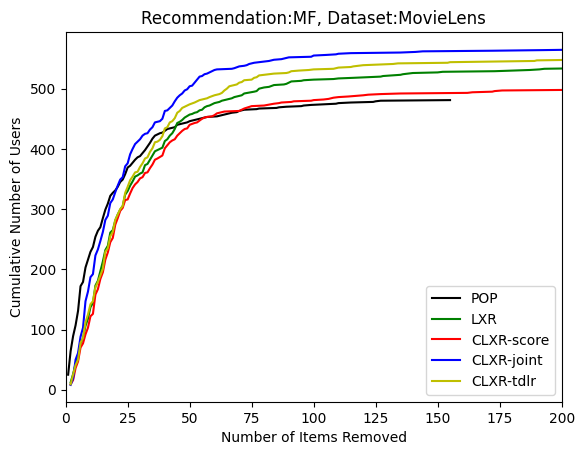

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# Example vector (replace with your actual data)

# Count the occurrences of each unique value
CLXR_frequency = Counter(CLXR[49])
sCLXR_frequency = Counter(sCLXR[49])
LXR_frequency = Counter(LXR[49])
TDLR_frequency = Counter(TDLR[49])
POP_frequency = Counter(POP)


# Prepare the x (number of items removed) and y (number of users) axes
x_CLXR = sorted(CLXR_frequency.keys())
y_CLXR = [CLXR_frequency[key] for key in x_CLXR]


x_sCLXR = sorted(sCLXR_frequency.keys())
y_sCLXR = [sCLXR_frequency[key] for key in x_sCLXR]

x_LXR = sorted(LXR_frequency.keys())
y_LXR = [LXR_frequency[key] for key in x_LXR]

x_POP = sorted(POP_frequency.keys())
y_POP = [POP_frequency[key] for key in x_POP]
x_TDLR = sorted(TDLR_frequency.keys())
y_TDLR = [TDLR_frequency[key] for key in x_TDLR]


# Compute the cumulative count
y_cumulative_CLXR = np.cumsum(y_CLXR)
y_cumulative_sCLXR = np.cumsum(y_sCLXR)
y_cumulative_LXR = np.cumsum(y_LXR)
y_cumulative_POP = np.cumsum(y_POP)

y_cumulative_TDLR = np.cumsum(y_TDLR)


# Plot the cumulative count
plt.plot(x_POP, y_cumulative_POP, linestyle='-', color='k', label="POP")
plt.plot(x_LXR, y_cumulative_LXR, linestyle='-', color='g', label="LXR")
plt.plot(x_sCLXR, y_cumulative_sCLXR, linestyle='-', color='r',label="CLXR-score")
plt.plot(x_CLXR, y_cumulative_CLXR, linestyle='-', color='b', label="CLXR-joint")
plt.plot(x_TDLR, y_cumulative_TDLR, linestyle='-', color='y',label="CLXR-tdlr")


plt.xlim(0, 200)  # Display only the range from [0,10]

# Customize the plot
plt.xlabel('Number of Items Removed')
plt.ylabel('Cumulative Number of Users')
plt.title('Recommendation:MF, Dataset:MovieLens')
plt.legend()
#plt.grid(True)
plt.savefig("MF-ML1m.jpeg")

# Show the plot
plt.show()

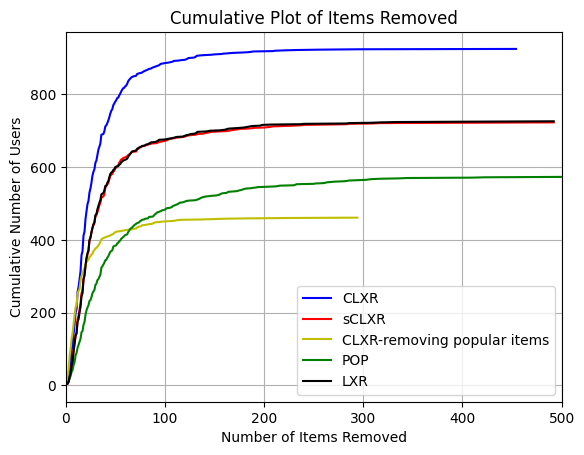

In [48]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# Example vector (replace with your actual data)

# Count the occurrences of each unique value

CLXR_frequency = Counter(CLXR_bin_indx[86])
sCLXR_frequency = Counter(sCLXR_bin_indx[36])
CLXRP_frequency = Counter(CLXRP_bin_indx[49])
POP_frequency = Counter(POP_bin_indx)
LXR_frequency = Counter(LXR_bin_indx[49])


# Prepare the x (number of items removed) and y (number of users) axes
x_CLXR = sorted(CLXR_frequency.keys())
y_CLXR = [CLXR_frequency[key] for key in x_CLXR]

x_sCLXR = sorted(sCLXR_frequency.keys())
y_sCLXR = [sCLXR_frequency[key] for key in x_sCLXR]

x_LXR = sorted(LXR_frequency.keys())
y_LXR = [LXR_frequency[key] for key in x_LXR]

x_CLXRP = sorted(CLXRP_frequency.keys())
y_CLXRP = [CLXRP_frequency[key] for key in x_CLXRP]

x_POP = sorted(POP_frequency.keys())
y_POP = [POP_frequency[key] for key in x_POP]
# Compute the cumulative count
y_cumulative_CLXR = np.cumsum(y_CLXR)
y_cumulative_sCLXR = np.cumsum(y_sCLXR)
y_cumulative_CLXRP = np.cumsum(y_CLXRP)
y_cumulative_POP = np.cumsum(y_POP)
y_cumulative_LXR = np.cumsum(y_LXR)

# Plot the cumulative count
plt.plot(x_CLXR, y_cumulative_CLXR,  linestyle='-', color='b', label="CLXR")
plt.plot(x_sCLXR, y_cumulative_sCLXR,  linestyle='-', color='r',label="sCLXR")
plt.plot(x_CLXRP, y_cumulative_CLXRP,  linestyle='-', color='y', label="CLXR-removing popular items")
plt.plot(x_POP, y_cumulative_POP,  linestyle='-', color='g',label="POP")
plt.plot(x_LXR, y_cumulative_LXR,  linestyle='-', color='k',label="LXR")

plt.xlim(0, 500)  # Display only the range from [0,10]

# Customize the plot
plt.xlabel('Number of Items Removed')
plt.ylabel('Cumulative Number of Users')
plt.title('Cumulative Plot of Items Removed')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [32]:

with open('New_bin_indx_CLXR_MLP_ML1m.pkl', 'rb') as file:
    CLXR_bin_indx= pickle.load(file) 

with open('New_total_items_CLXR_MLP_ML1m.pkl', 'rb') as file:
    CLXR_tot_items= pickle.load(file)  

with open('New_bin_indx_LXR_MLP_ML1m.pkl', 'rb') as file:
    LXR_bin_indx= pickle.load(file) 

with open('New_total_items_LXR_MLP_ML1m.pkl', 'rb') as file:
    LXR_tot_items= pickle.load(file)  

In [36]:
from collections import Counter

x=[]
for i in range (50):
    CLXR_frequency = Counter(CLXR_bin_indx[i])
    x_CLXR = sorted(CLXR_frequency.keys())
    y_CLXR = [CLXR_frequency[key] for key in x_CLXR]
    y_cumulative_CLXR = np.cumsum(y_CLXR)
    x.append(np.max(y_cumulative_CLXR))
np.argmax(x)

np.int64(25)

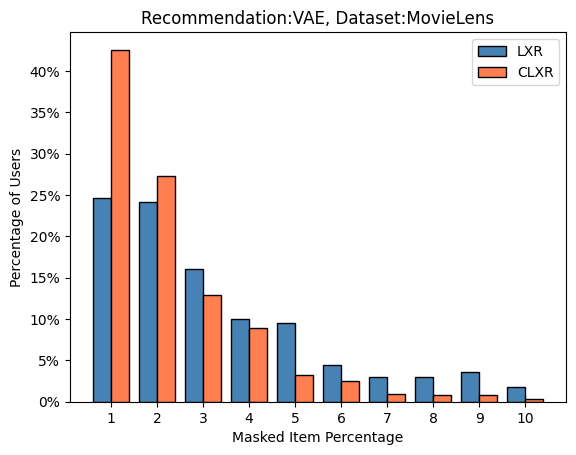

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Example data for two datasets
data_lxr = LXR_bin_indx[42]
data_clxr = CLXR_bin_indx[41]



# Define the bin edges
bin_edges = np.arange(1, 12)  # 1–11 (10 bins for integers 1 to 10)

# Calculate histograms for both datasets, normalized to sum to 1
hist_lxr, _ = np.histogram(data_lxr, bins=bin_edges)
hist_clxr, _ = np.histogram(data_clxr, bins=bin_edges)

# Normalize the histograms so they show percentages
hist_lxr = hist_lxr / len(data_lxr) * 100  # Convert to percentage
hist_clxr = hist_clxr / len(data_clxr) * 100  # Convert to percentage

# Compute bin centers for the x-axis ticks
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# Width of each bar
bar_width = 0.4

# Plot histograms side by side
plt.bar(bin_centers - bar_width / 2, hist_lxr, width=bar_width, label="LXR", color="steelblue", edgecolor="black")
plt.bar(bin_centers + bar_width / 2, hist_clxr, width=bar_width, label="CLXR", color="coral", edgecolor="black")

# Add labels, title, and legend
plt.xlabel("Masked Item Percentage")
plt.ylabel("Percentage of Users")
plt.xticks(bin_centers, [str(int(c)) for c in bin_centers])  # Custom x-axis labels (1, 2, ..., 10)

# Format y-axis as percentages
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda val, pos: f'{val:.0f}%'))

# Show the legend
plt.legend()
plt.title('Recommendation:VAE, Dataset:MovieLens')
plt.savefig("hist_comparison_VAE_ML-1m.jpeg")
# Show the plot
plt.show()
